In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import sys
print(sys.executable)

/opt/homebrew/Caskroom/miniforge/base/envs/tuberculosis/bin/python


In [9]:
# ── 0. Download dataset from kaggle ──────────────────────────────────────────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter
import kaggle

! kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset -p /Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
100%|███████████████████████████████████████▉| 662M/663M [00:53<00:00, 11.7MB/s]
100%|████████████████████████████████████████| 663M/663M [00:53<00:00, 12.9MB/s]


In [11]:
import zipfile 
zf = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/tuberculosis-tb-chest-xray-dataset.zip'
target_dir = "/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets"
zfile = zipfile.ZipFile(zf)
zfile.extractall(target_dir)

In [12]:
import splitfolders

splitfolders.ratio(
    "/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/TB_Chest_Radiography_Database",
    output="/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn",
    seed=1337,
    ratio=(.7, .2, .1), 
    group_prefix=None
)

Copying files: 4200 files [00:01, 2151.51 files/s]


DERICTORIES

In [23]:
train_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn/train'
test_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn/test'
valid_path = '/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/datasets/cnn/val'

In [24]:
batch_size = 16 
img_height = 500
img_width = 500

Data augmentation

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Create Image Data Generator for Train Set
image_gen = ImageDataGenerator(
                                rescale = 1./255,
                                #shear_range = 0,
                                #zoom_range = 0,
                                horizontal_flip = True,          
                               )
# Create Image Data Generator for Test/Validation Set
test_data_gen = ImageDataGenerator(rescale = 1./255)

In [26]:
train = image_gen.flow_from_directory(
      train_path,
      target_size=(img_height, img_width),
      color_mode='grayscale',
      class_mode='binary',
      batch_size=batch_size
      )

test = test_data_gen.flow_from_directory(
      test_path,
      target_size=(img_height, img_width),
      color_mode='grayscale',
      shuffle=False, 
      class_mode='binary',
      batch_size=batch_size
      )

valid = test_data_gen.flow_from_directory(
      valid_path,
      target_size=(img_height, img_width),
      color_mode='grayscale',
      class_mode='binary', 
      batch_size=batch_size
      )

Found 2939 images belonging to 2 classes.
Found 421 images belonging to 2 classes.
Found 840 images belonging to 2 classes.


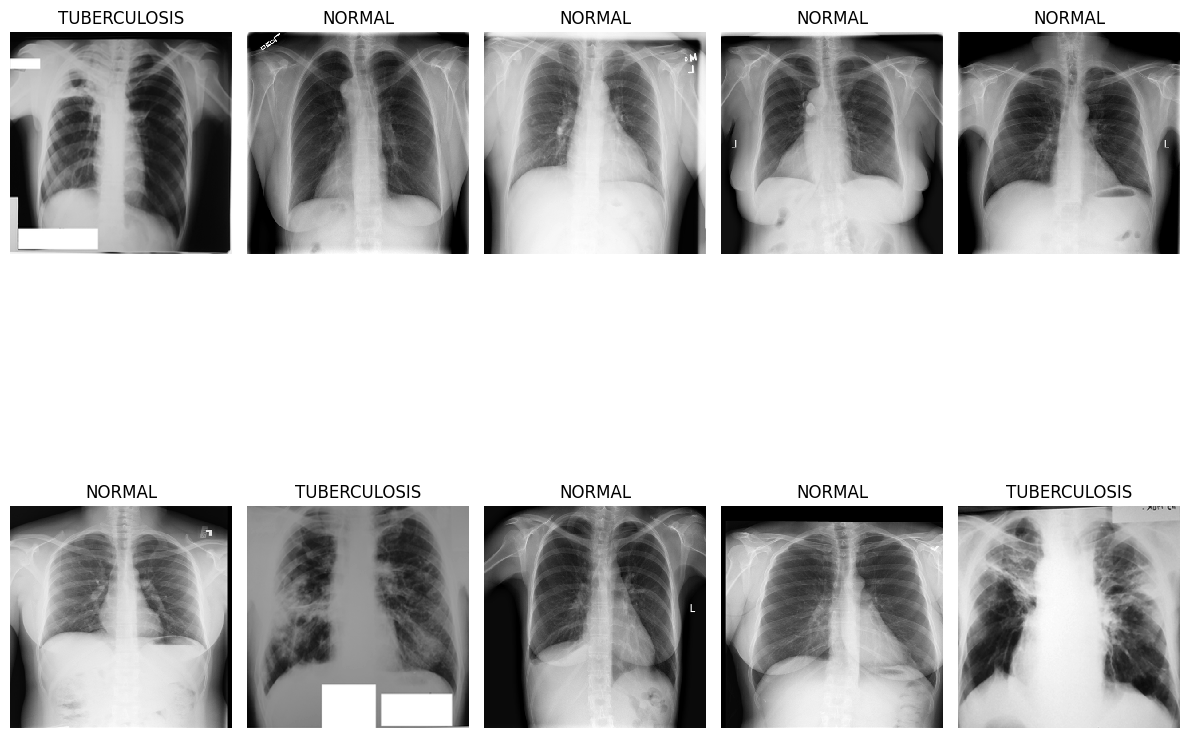

In [28]:
import matplotlib.pyplot as plt 
import numpy as np              
import pandas as pd 

plt.figure(figsize=(12, 12))
for i in range(0, 10):
    plt.subplot(2, 5, i+1)
    for X_batch, Y_batch in train:
        image = X_batch[0]        
        dic = {0:'NORMAL', 1:'TUBERCULOSIS'}
        plt.title(dic.get(Y_batch[0]))
        plt.axis('off')
        plt.imshow(np.squeeze(image),cmap='gray',interpolation='nearest')
        break
plt.tight_layout()
plt.show()

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

CNN architecture

In [30]:
cnn = Sequential()
cnn.add(Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 1)))
cnn.add(MaxPooling2D(pool_size = (2, 2)))
cnn.add(Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 1)))
cnn.add(MaxPooling2D(pool_size = (2, 2)))
cnn.add(Conv2D(32, (3, 3), activation="relu", input_shape=(img_width, img_height, 1)))
cnn.add(MaxPooling2D(pool_size = (2, 2)))
cnn.add(Conv2D(64, (3, 3), activation="relu", input_shape=(img_width, img_height, 1)))
cnn.add(MaxPooling2D(pool_size = (2, 2)))
cnn.add(Conv2D(64, (3, 3), activation="relu", input_shape=(img_width, img_height, 1)))
cnn.add(MaxPooling2D(pool_size = (2, 2)))
cnn.add(Flatten())
cnn.add(Dense(activation = 'relu', units = 128))
cnn.add(Dense(activation = 'relu', units = 64))
cnn.add(Dense(activation = 'sigmoid', units = 1))

2026-02-28 15:12:19.867020: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-28 15:12:19.867484: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-28 15:12:19.868357: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-28 15:12:19.868949: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-28 15:12:19.869835: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [31]:
cnn.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

Fit model

In [32]:
early = EarlyStopping(monitor= "val_loss", mode= "min", patience= 3)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)
callbacks_list = [ early, learning_rate_reduction]

In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train.classes),
    y=train.classes
)

cw = dict(zip(np.unique(train.classes), weights))
print(cw)

{0: 0.5997959183673469, 1: 3.005112474437628}


In [36]:
cnn.fit(train,epochs=25, validation_data=valid, class_weight=cw, callbacks=callbacks_list)

Epoch 1/25


2026-02-28 15:18:35.472021: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


184/184 [==============================] - 32s 157ms/step - loss: 0.5066 - accuracy: 0.7584 - val_loss: 0.4636 - val_accuracy: 0.7750 - lr: 0.0010
Epoch 2/25
184/184 [==============================] - 28s 153ms/step - loss: 0.2918 - accuracy: 0.8636 - val_loss: 0.1823 - val_accuracy: 0.9452 - lr: 0.0010
Epoch 3/25
184/184 [==============================] - 29s 159ms/step - loss: 0.2309 - accuracy: 0.9010 - val_loss: 0.2708 - val_accuracy: 0.8524 - lr: 0.0010
Epoch 4/25
184/184 [==============================] - ETA: 0s - loss: 0.2244 - accuracy: 0.9126
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
184/184 [==============================] - 29s 160ms/step - loss: 0.2244 - accuracy: 0.9126 - val_loss: 0.7681 - val_accuracy: 0.7548 - lr: 0.0010
Epoch 5/25
184/184 [==============================] - 30s 165ms/step - loss: 0.1651 - accuracy: 0.9265 - val_loss: 0.1143 - val_accuracy: 0.9583 - lr: 3.0000e-04
Epoch 6/25
184/184 [==============================] - 36

<Axes: >

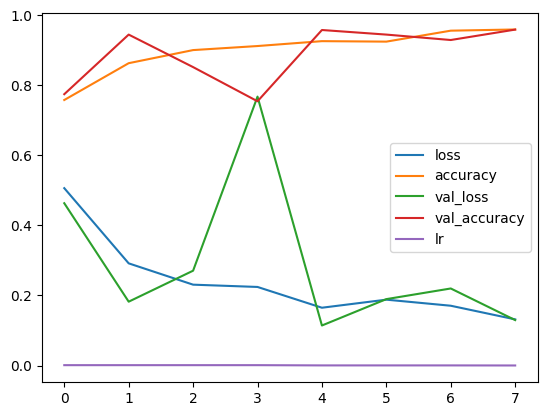

In [37]:
pd.DataFrame(cnn.history.history).plot()

In [38]:
test_accu = cnn.evaluate(test)
print('The testing accuracy is :',test_accu[1]*100, '%')

27/27 [==============================] - 2s 57ms/step - loss: 0.2084 - accuracy: 0.9572
The testing accuracy is : 95.72446346282959 %


In [ ]:
preds = cnn.predict(test,verbose=1)

27/27 [==============================] - 1s 48ms/step


In [40]:
predictions = preds.copy()
predictions[predictions <= 0.5] = 0
predictions[predictions > 0.5] = 1

<Axes: >

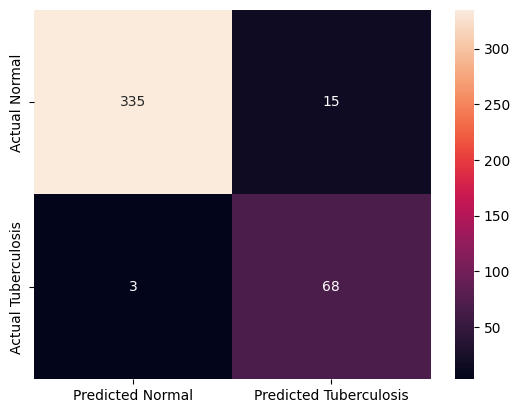

In [42]:
from sklearn.metrics import classification_report,confusion_matrix
cm = pd.DataFrame(data=confusion_matrix(test.classes, predictions, labels=[0, 1]),index=["Actual Normal", "Actual Tuberculosis"],
columns=["Predicted Normal", "Predicted Tuberculosis"])

import seaborn as sns
sns.heatmap(cm,annot=True,fmt="d")

In [43]:
print(classification_report(y_true=test.classes,y_pred=predictions,target_names =['NORMAL','TUBERCULOSIS']))

              precision    recall  f1-score   support

      NORMAL       0.99      0.96      0.97       350
TUBERCULOSIS       0.82      0.96      0.88        71

    accuracy                           0.96       421
   macro avg       0.91      0.96      0.93       421
weighted avg       0.96      0.96      0.96       421



(421, 500, 500, 1)
(421,)


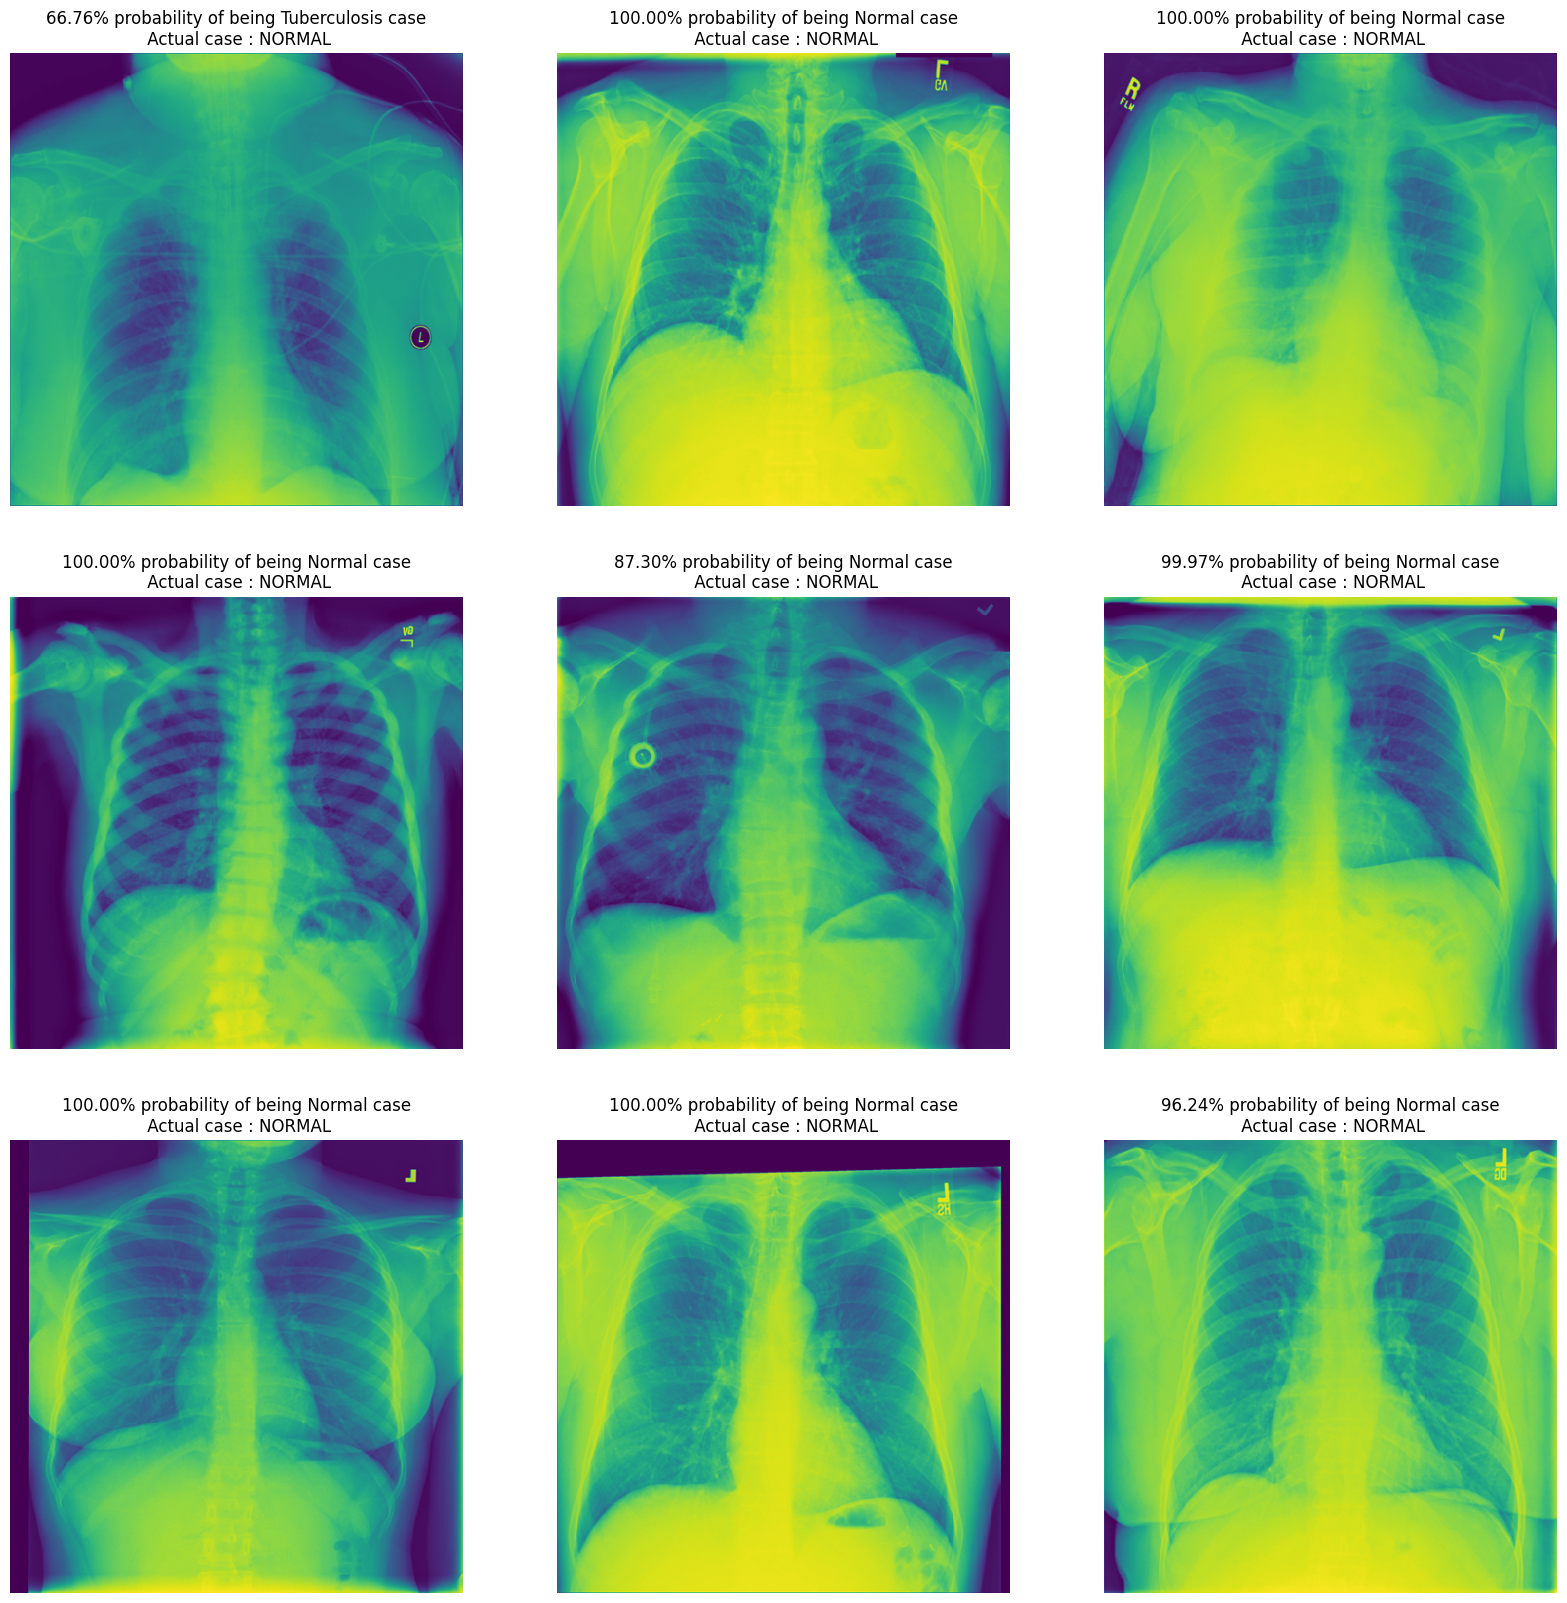

In [44]:
test.reset()
x=np.concatenate([test.next()[0] for i in range(test.__len__())])
y=np.concatenate([test.next()[1] for i in range(test.__len__())])
print(x.shape)
print(y.shape)
#this little code above extracts the images from test Data iterator without shuffling the sequence
# x contains image array and y has labels 
dic = {0:'NORMAL', 1:'TUBERCULOSIS'}
plt.figure(figsize=(20,20))
for i in range(0+228, 9+228):
  plt.subplot(3, 3, (i-228)+1)
  if preds[i, 0] >= 0.5: 
    out = ('{:.2%} probability of being Tuberculosis case'.format(preds[i][0]))
      
      
  else: 
    out = ('{:.2%} probability of being Normal case'.format(1-preds[i][0]))
  plt.title(out+"\n Actual case : "+ dic.get(y[i]))    
  plt.imshow(np.squeeze(x[i]))
  plt.axis('off')
plt.show()

In [47]:
cnn.save(filepath='/Users/Ahmad/UNI-work/year3/FYP/Project/tuberculosis/models/trained/tuberculosis_X_ray.keras')